<a href="https://colab.research.google.com/github/Ruchika0912/BCSE331L-EDA-Course-Project/blob/main/EDA_Project_Ruchika_Tuteja.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# B C S E 3 3 1 L — Exploratory Data Analysis Course Project
## Analysis of Police Shooting Incidents

**Student:** Ruchika Tuteja  
**Register Number:** 23BDS0050  
**Course:** BCSE331L – Exploratory Data Analysis  

### Project objective
This project performs systematic exploratory analysis of the assigned `shootings.csv` dataset. It covers Phase I and Phase II requirements using the **same notebook**:
- Data loading, statistical summary, missing-value handling, cleaning and transformation
- Univariate, bivariate and multivariate visual analysis
- 1D, 2D and 3D statistical/visual analysis
- K-Means clustering
- Hierarchical clustering

> The dataset is loaded directly from the faculty-provided GitHub raw URL, so the original dataset is not duplicated unnecessarily in this repository.


In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")


Libraries imported successfully.


## 1. Load the dataset

In [2]:
DATA_URL = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/shootings.csv"

df = pd.read_csv(DATA_URL)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (4895, 15)


,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera,arms_category
0,3,Tim Elliot,02/01/15,shot,gun,53.0,M,Asian,Shelton,WA,True,attack,Not fleeing,FALSE,Guns
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.0,M,White,Aloha,OR,False,attack,Not fleeing,FALSE,Guns
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.0,M,Hispanic,Wichita,KS,False,other,Not fleeing,FALSE,Unarmed
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.0,M,White,San Francisco,CA,True,attack,Not fleeing,FALSE,Other unusual objects
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.0,M,Hispanic,Evans,CO,False,attack,Not fleeing,FALSE,Piercing objects


## 2. Basic dataset inspection

In [3]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nDataset information:")
df.info()

print("\nDuplicate rows:", df.duplicated().sum())


Column names:
['id', 'name', 'date', 'manner_of_death', 'armed', 'age', 'gender', 'race', 'city', 'state', 'signs_of_mental_illness', 'threat_level', 'flee', 'body_camera', 'arms_category']

Data types:


,dtype
id,int64
name,object
date,object
manner_of_death,object
armed,object
age,float64
gender,object
race,object
city,object
state,object



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4895 entries, 0 to 4894
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       4895 non-null   int64  
 1   name                     4895 non-null   object 
 2   date                     4895 non-null   object 
 3   manner_of_death          4892 non-null   object 
 4   armed                    4895 non-null   object 
 5   age                      4895 non-null   float64
 6   gender                   4895 non-null   object 
 7   race                     4893 non-null   object 
 8   city                     4895 non-null   object 
 9   state                    4895 non-null   object 
 10  signs_of_mental_illness  4895 non-null   bool   
 11  threat_level             4895 non-null   object 
 12  flee                     4895 non-null   object 
 13  body_camera              4895 non-null   object 
 14  ar

## 3. Basic statistical analysis

In [4]:
print("Numerical descriptive statistics:")
display(df.describe(include=[np.number]).T)

print("Categorical descriptive statistics:")
display(df.describe(include=["object", "bool"]).T)


Numerical descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
id,4895.0,2902.148519,1683.467910,3.0,1441.5,2847.0,4352.5,5925.0
age,4895.0,36.549750,12.694348,6.0,27.0,35.0,45.0,91.0


Categorical descriptive statistics:


,count,unique,top,freq
name,4895,4851,TK TK,29
date,4895,1792,29/06/18,9
manner_of_death,4892,2,shot,4644
armed,4895,89,gun,2755
gender,4895,3,M,4672
race,4893,6,White,2474
city,4895,2288,Los Angeles,78
state,4895,51,CA,701
signs_of_mental_illness,4895,2,False,3792
threat_level,4895,3,attack,3160


## 4. Missing-data analysis

In [5]:
# Treat common placeholders as missing values
df = df.replace(["?", "NA", "N/A", "Unknown"], np.nan)

missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": missing_pct
})

display(missing_table[missing_table["Missing Values"] > 0])


,Missing Values,Missing Percentage
arms_category,420,8.58
manner_of_death,3,0.06
race,2,0.04
body_camera,2,0.04
gender,1,0.02


## 5. Data cleaning

In [6]:
# Boolean columns: safely convert True/False-style values to nullable booleans
def to_nullable_bool(series):
    mapping = {
        "true": True, "false": False,
        "yes": True, "no": False,
        "1": True, "0": False,
        "t": True, "f": False
    }
    normalized = series.astype("string").str.strip().str.lower()
    return normalized.map(mapping).astype("boolean")

for col in ["signs_of_mental_illness", "body_camera"]:
    if col in df.columns:
        df[col] = to_nullable_bool(df[col])

# Remove exact duplicate rows
df = df.drop_duplicates().copy()

print("Shape after removing duplicates:", df.shape)
print("\nMissing values after cleaning:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing"))


Shape after removing duplicates: (4895, 15)

Missing values after cleaning:


,missing
arms_category,420
manner_of_death,3
race,2
body_camera,2
gender,1
date,0
id,0
age,0
armed,0
name,0


## 6. Data transformation / feature engineering

In [7]:
# Create useful time-based variables
# Ensure date is datetime before using the .dt accessor.
df["date"] = pd.to_datetime(df["date"], errors="coerce", dayfirst=True)

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.day_name()

# Binary versions for analysis
def bool_to_float(series):
    normalized = series.astype("string").str.strip().str.lower()
    mapping = {
        "true": 1.0, "false": 0.0,
        "yes": 1.0, "no": 0.0,
        "1": 1.0, "0": 0.0,
        "t": 1.0, "f": 0.0
    }
    return normalized.map(mapping)

df["mental_illness_binary"] = bool_to_float(df["signs_of_mental_illness"])
df["body_camera_binary"] = bool_to_float(df["body_camera"])

print("Transformed dataset:")
display(df.head())


Transformed dataset:


/tmp/ipykernel_820/2706976032.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"], errors="coerce", dayfirst=True)


,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera,arms_category,year,month,day,day_of_week,mental_illness_binary,body_camera_binary
0,3,Tim Elliot,2015-01-02,shot,gun,53.0,M,Asian,Shelton,WA,True,attack,Not fleeing,False,Guns,2015,1,2,Friday,1.0,0.0
1,4,Lewis Lee Lembke,2015-01-02,shot,gun,47.0,M,White,Aloha,OR,False,attack,Not fleeing,False,Guns,2015,1,2,Friday,0.0,0.0
2,5,John Paul Quintero,2015-01-03,shot and Tasered,unarmed,23.0,M,Hispanic,Wichita,KS,False,other,Not fleeing,False,Unarmed,2015,1,3,Saturday,0.0,0.0
3,8,Matthew Hoffman,2015-01-04,shot,toy weapon,32.0,M,White,San Francisco,CA,True,attack,Not fleeing,False,Other unusual objects,2015,1,4,Sunday,1.0,0.0
4,9,Michael Rodriguez,2015-01-04,shot,nail gun,39.0,M,Hispanic,Evans,CO,False,attack,Not fleeing,False,Piercing objects,2015,1,4,Sunday,0.0,0.0


## 7. Univariate / 1D analysis

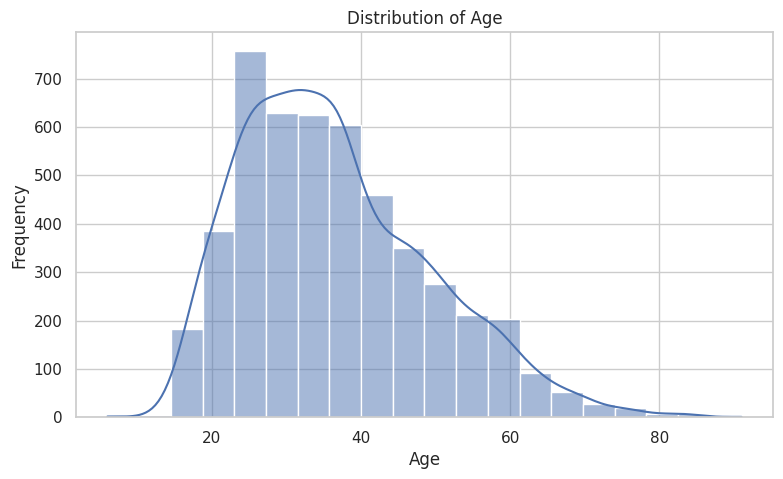

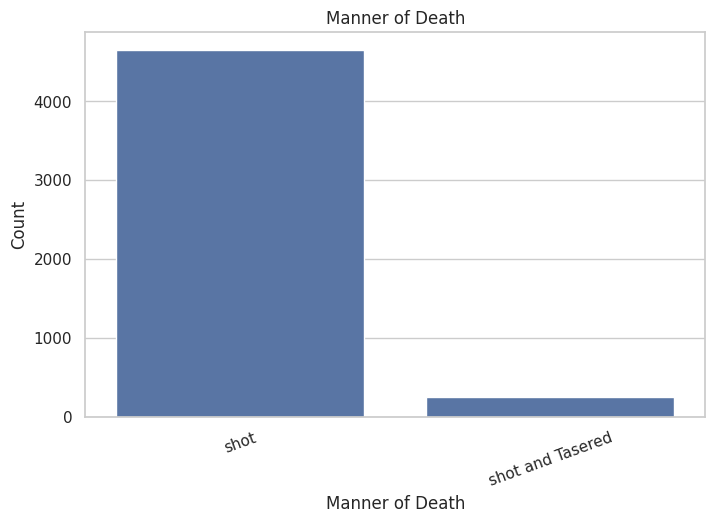

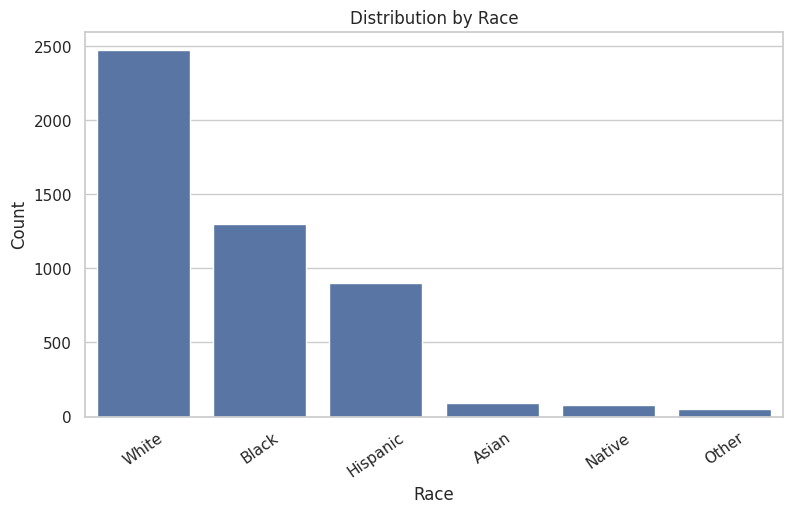

In [8]:
# 1D analysis 1: Age distribution
plt.figure(figsize=(9, 5))
sns.histplot(df["age"].dropna(), bins=20, kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# 1D analysis 2: Manner of death
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="manner_of_death", order=df["manner_of_death"].value_counts().index)
plt.title("Manner of Death")
plt.xlabel("Manner of Death")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

# 1D analysis 3: Race distribution
plt.figure(figsize=(9, 5))
order = df["race"].value_counts().index
sns.countplot(data=df, x="race", order=order)
plt.title("Distribution by Race")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks(rotation=35)
plt.show()


## 8. Bivariate / 2D analysis

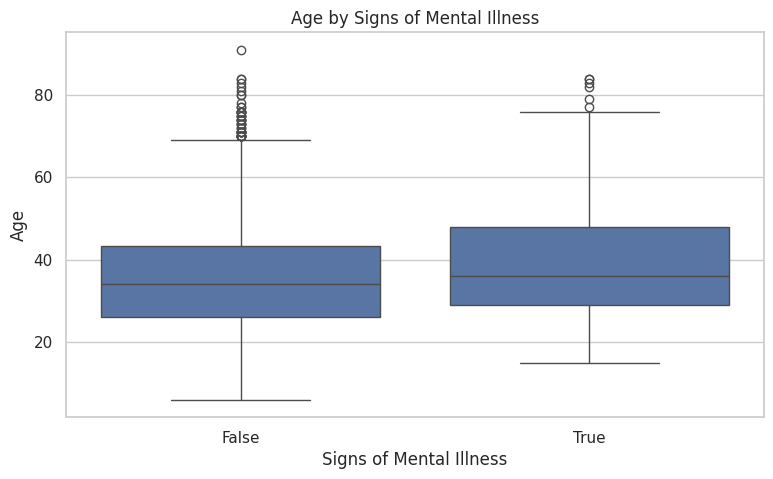

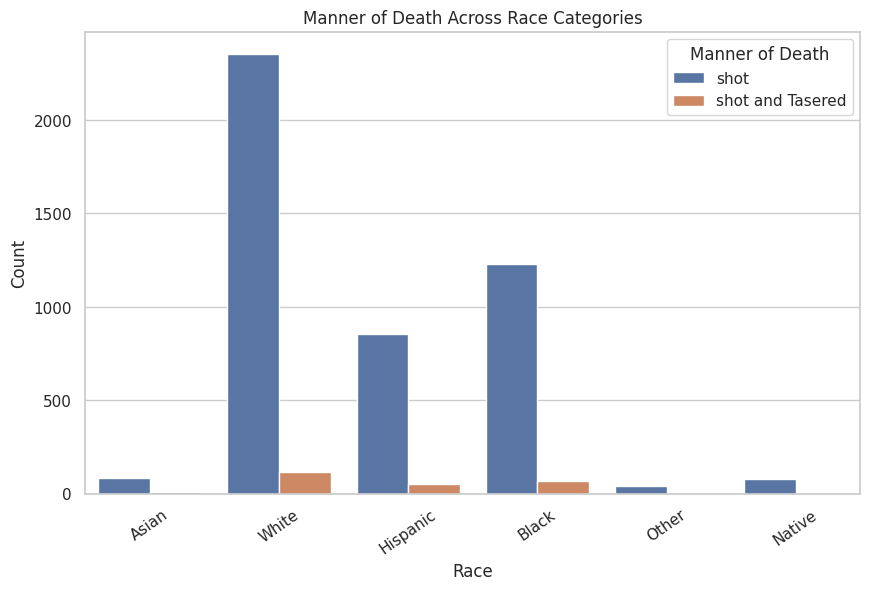

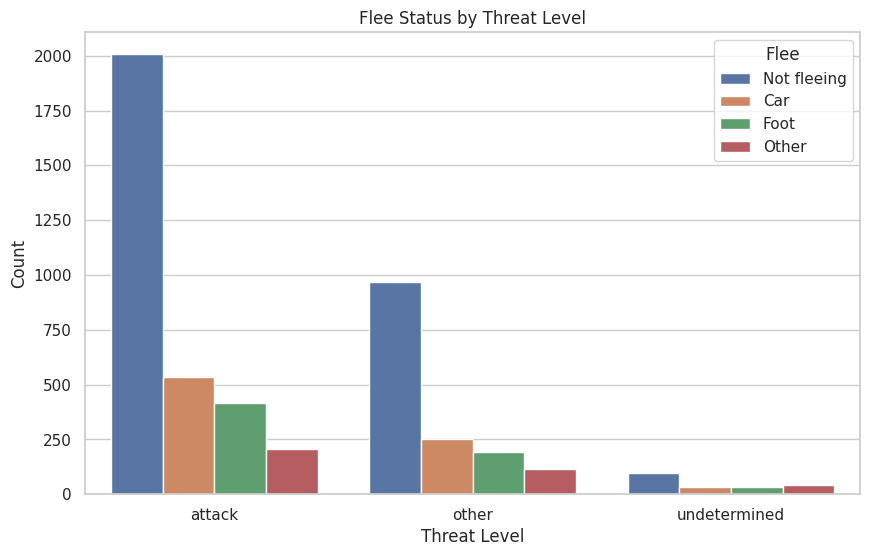

In [9]:
# 2D analysis 1: Age vs signs of mental illness
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="signs_of_mental_illness", y="age")
plt.title("Age by Signs of Mental Illness")
plt.xlabel("Signs of Mental Illness")
plt.ylabel("Age")
plt.show()

# 2D analysis 2: Race vs manner of death
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="race", hue="manner_of_death")
plt.title("Manner of Death Across Race Categories")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks(rotation=35)
plt.legend(title="Manner of Death")
plt.show()

# 2D analysis 3: Threat level vs flee status
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="threat_level", hue="flee")
plt.title("Flee Status by Threat Level")
plt.xlabel("Threat Level")
plt.ylabel("Count")
plt.legend(title="Flee")
plt.show()


## 9. Multivariate / 3D analysis

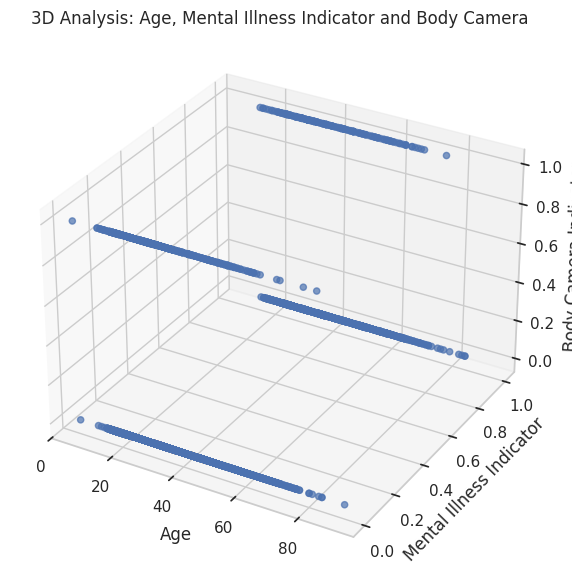

In [10]:
# Prepare three numeric variables for a 3D scatter plot
plot3d = df[["age", "mental_illness_binary", "body_camera_binary"]].dropna().copy()

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    plot3d["age"],
    plot3d["mental_illness_binary"],
    plot3d["body_camera_binary"],
    alpha=0.7
)

ax.set_title("3D Analysis: Age, Mental Illness Indicator and Body Camera")
ax.set_xlabel("Age")
ax.set_ylabel("Mental Illness Indicator")
ax.set_zlabel("Body Camera Indicator")
plt.show()


## 10. Correlation analysis

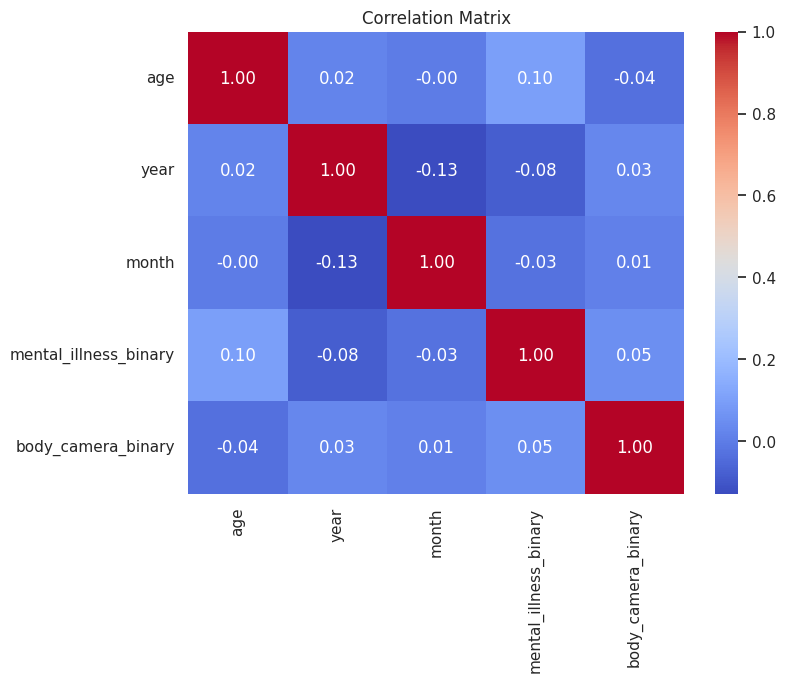

,age,year,month,mental_illness_binary,body_camera_binary
age,1.000000,0.021097,-0.001654,0.096865,-0.035613
year,0.021097,1.000000,-0.128817,-0.081474,0.029643
month,-0.001654,-0.128817,1.000000,-0.028345,0.010800
mental_illness_binary,0.096865,-0.081474,-0.028345,1.000000,0.049754
body_camera_binary,-0.035613,0.029643,0.010800,0.049754,1.000000


In [11]:
corr_cols = ["age", "year", "month", "mental_illness_binary", "body_camera_binary"]
corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

display(corr)


## 11. Additional multivariate visualization

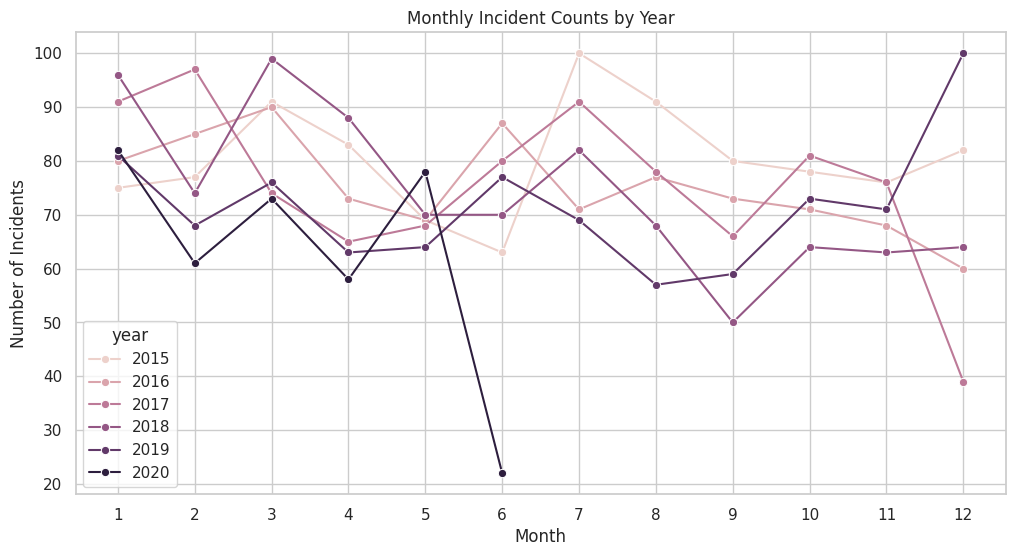

In [12]:
# Monthly incidents by year
monthly = (
    df.dropna(subset=["year", "month"])
      .groupby(["year", "month"])
      .size()
      .reset_index(name="incidents")
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly, x="month", y="incidents", hue="year", marker="o")
plt.title("Monthly Incident Counts by Year")
plt.xlabel("Month")
plt.ylabel("Number of Incidents")
plt.xticks(range(1, 13))
plt.show()


## 12. K-Means clustering

In [13]:
# Select mixed categorical/numeric features and encode categories
cluster_cols = [
    "age", "mental_illness_binary", "body_camera_binary",
    "manner_of_death", "threat_level", "flee", "gender"
]

cluster_df = df[cluster_cols].copy()

# Fill numeric missing values with median
for col in ["age", "mental_illness_binary", "body_camera_binary"]:
    cluster_df[col] = cluster_df[col].fillna(cluster_df[col].median())

# Fill categorical missing values with mode
for col in ["manner_of_death", "threat_level", "flee", "gender"]:
    mode = cluster_df[col].mode(dropna=True)
    cluster_df[col] = cluster_df[col].fillna(mode.iloc[0] if len(mode) else "Missing")

# One-hot encode categorical variables
X = pd.get_dummies(
    cluster_df,
    columns=["manner_of_death", "threat_level", "flee", "gender"],
    drop_first=False
)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Clustering matrix shape:", X_scaled.shape)


Clustering matrix shape: (4895, 14)


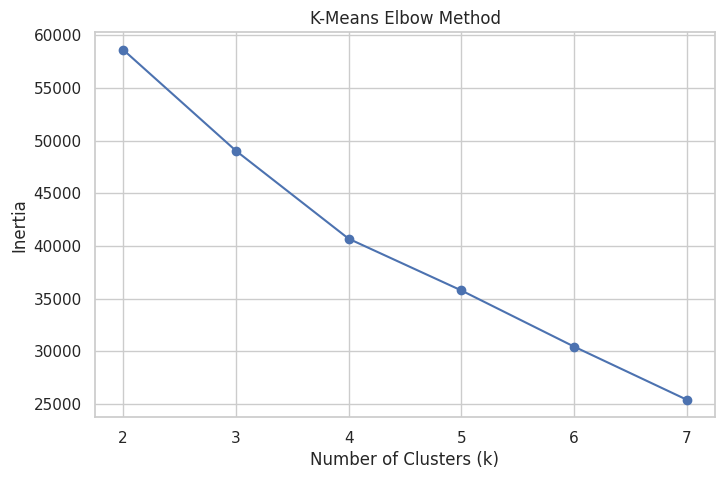

In [14]:
# Elbow method
inertias = []
K = range(2, 8)

for k in K:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(K), inertias, marker="o")
plt.title("K-Means Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(list(K))
plt.show()


In [15]:
# Use k=3 as a simple, interpretable clustering solution
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

print("K-Means cluster counts:")
display(df["kmeans_cluster"].value_counts().sort_index())

print("Cluster-wise age summary:")
display(df.groupby("kmeans_cluster")["age"].agg(["count", "mean", "median", "min", "max"]))


K-Means cluster counts:


,count
kmeans_cluster,
0,4431
1,222
2,242


Cluster-wise age summary:


,count,mean,median,min,max
kmeans_cluster,,,,,
0,4431,36.538126,34.0,6.0,91.0
1,222,37.019080,35.0,12.0,84.0
2,242,36.332040,35.0,15.0,76.0


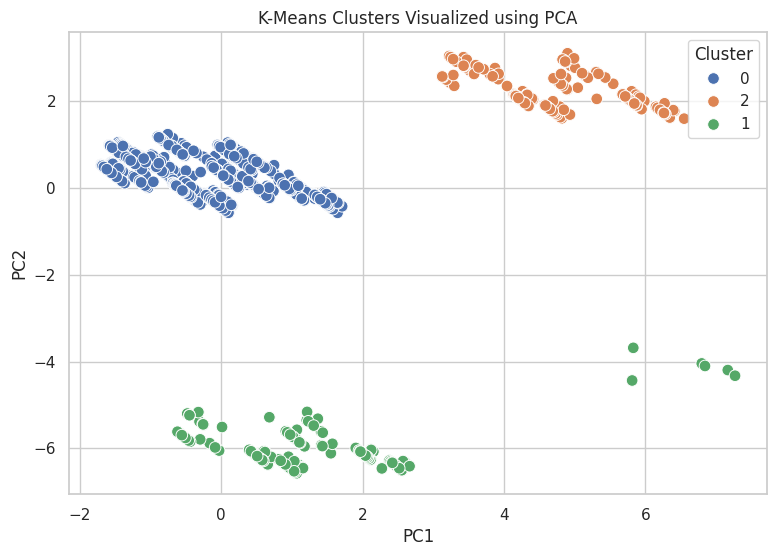

Explained variance ratio: [0.15438356 0.14674266]


In [16]:
# PCA visualization of K-Means clusters
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": df["kmeans_cluster"].astype(str).values
})

plt.figure(figsize=(9, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Cluster", s=70)
plt.title("K-Means Clusters Visualized using PCA")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)


## 13. Hierarchical clustering

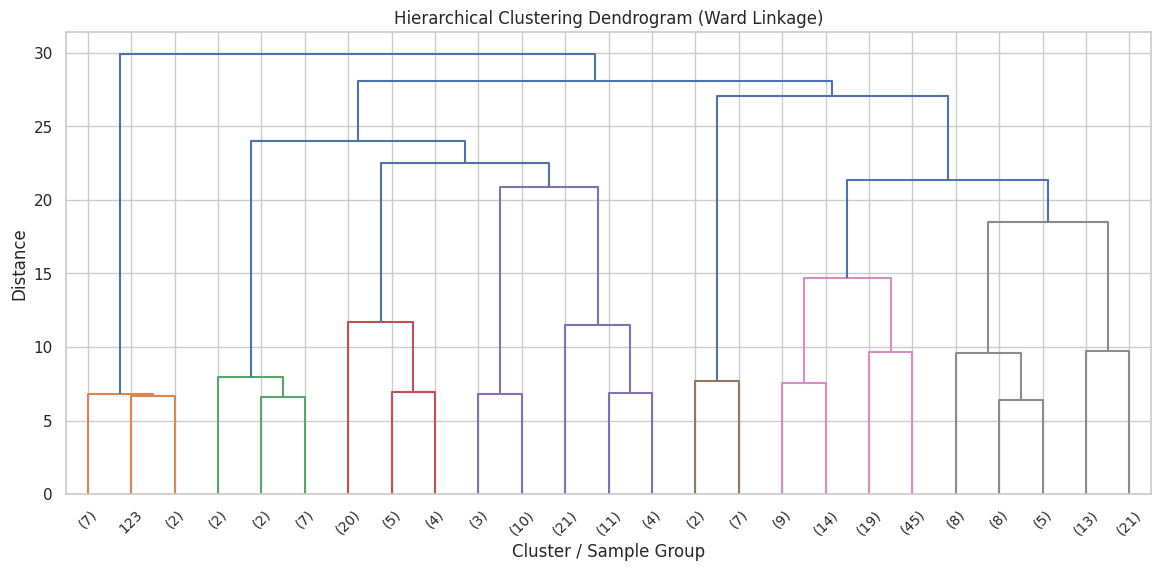

In [17]:
# Dendrogram using a sample when the dataset is large
sample_n = min(250, len(X_scaled))
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_scaled), size=sample_n, replace=False)
X_sample = X_scaled[sample_idx]

Z = linkage(X_sample, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode="lastp", p=25)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Cluster / Sample Group")
plt.ylabel("Distance")
plt.show()


In [18]:
# Agglomerative clustering with 3 clusters
hier = AgglomerativeClustering(n_clusters=3, linkage="ward")
df["hierarchical_cluster"] = hier.fit_predict(X_scaled)

print("Hierarchical cluster counts:")
display(df["hierarchical_cluster"].value_counts().sort_index())

print("Cluster-wise age summary:")
display(df.groupby("hierarchical_cluster")["age"].agg(["count", "mean", "median", "min", "max"]))


Hierarchical cluster counts:


,count
hierarchical_cluster,
0,4431
1,222
2,242


Cluster-wise age summary:


,count,mean,median,min,max
hierarchical_cluster,,,,,
0,4431,36.538126,34.0,6.0,91.0
1,222,37.019080,35.0,12.0,84.0
2,242,36.332040,35.0,15.0,76.0


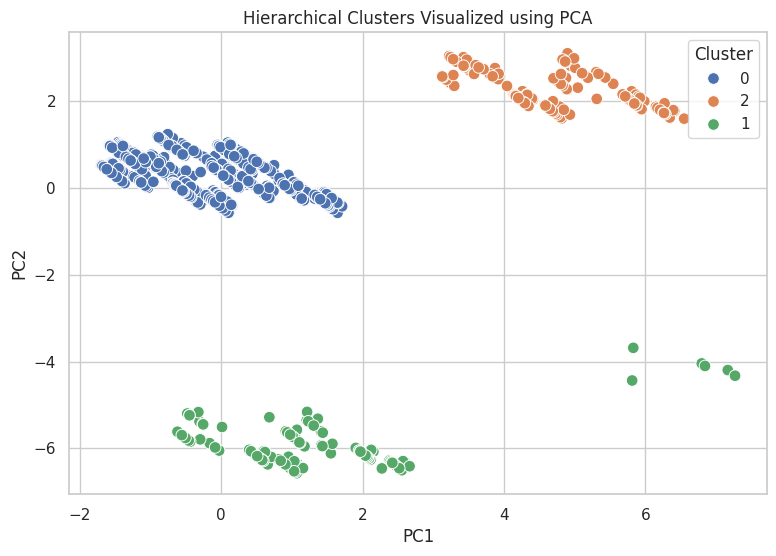

In [19]:
# PCA visualization of hierarchical clusters
hier_pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": df["hierarchical_cluster"].astype(str).values
})

plt.figure(figsize=(9, 6))
sns.scatterplot(data=hier_pca_df, x="PC1", y="PC2", hue="Cluster", s=70)
plt.title("Hierarchical Clusters Visualized using PCA")
plt.show()


## 14. Key observations

Use the actual outputs above to write 5–8 observations after running the notebook. Examples of the **type** of observation to report are:
1. Describe the central tendency and spread of age using the numerical summary.
2. Identify the most frequent categories in manner of death, threat level and race.
3. Report the amount and percentage of missing data before and after cleaning.
4. Describe visible relationships in the 2D plots without making causal claims.
5. Report the correlation values shown in the correlation matrix.
6. Describe the approximate clustering structure from K-Means and hierarchical clustering.
7. Compare cluster sizes and age summaries using the generated tables.

**Important:** Replace generic wording with the actual values produced by your run.


## 15. Conclusion

The project demonstrates a complete EDA workflow on the assigned shootings dataset, from data loading and cleaning to statistical analysis, visualization and clustering. The analysis combines 1D, 2D and 3D exploration with K-Means and hierarchical clustering to identify patterns and groupings in the available incident-level variables. The results are descriptive and should not be interpreted as causal explanations.
